In [2]:
!pip install imblearn
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
%matplotlib inline

In [4]:
# Load the dataset
df = pd.read_csv('fitness_class_2212.csv')  # Replace with your file path

# Display dataset info
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (1500, 8)

First 5 Rows:


,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


In [6]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
booking_id           0
months_as_member     0
weight              20
days_before          0
day_of_week          0
time                 0
category             0
attended             0
dtype: int64


In [21]:
df['days_before'] = pd.to_numeric(df['days_before'], errors='coerce')

In [23]:
# Option 2: Impute missing values 

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

# Fit and transform only the 'weight' column
# Note: We use [[ ]] to keep it as a 2D array, which the imputer requires
df['weight'] = imputer.fit_transform(df[['weight']])

## Assignment #1: EDA

### Descriptive Statistics

In [26]:
print("Dataset Overview:")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1] - 1}")

Dataset Overview:
Total Samples: 1500
Total Features: 7


In [28]:
print("Feature Summary:")
print(df.describe())

Feature Summary:
        booking_id  months_as_member       weight  days_before     attended
count  1500.000000       1500.000000  1500.000000  1475.000000  1500.000000
mean    750.500000         15.628667    82.610378     8.347797     0.302667
std     433.157015         12.926543    12.680411     4.080647     0.459565
min       1.000000          1.000000    55.410000     1.000000     0.000000
25%     375.750000          8.000000    73.562500     4.000000     0.000000
50%     750.500000         12.000000    81.035000     9.000000     0.000000
75%    1125.250000         19.000000    89.382500    12.000000     1.000000
max    1500.000000        148.000000   170.520000    29.000000     1.000000


In [30]:
# Attendance proportion

print("\nAttendance Distribution")
print(df['attended'].value_counts(normalize=True)*100)


Attendance Distribution
attended
0    69.733333
1    30.266667
Name: proportion, dtype: float64


Approximately 70% of bookings resulted in a "No-show" (0), while only 30% of members actually attended the class (1). 

### Visualisations

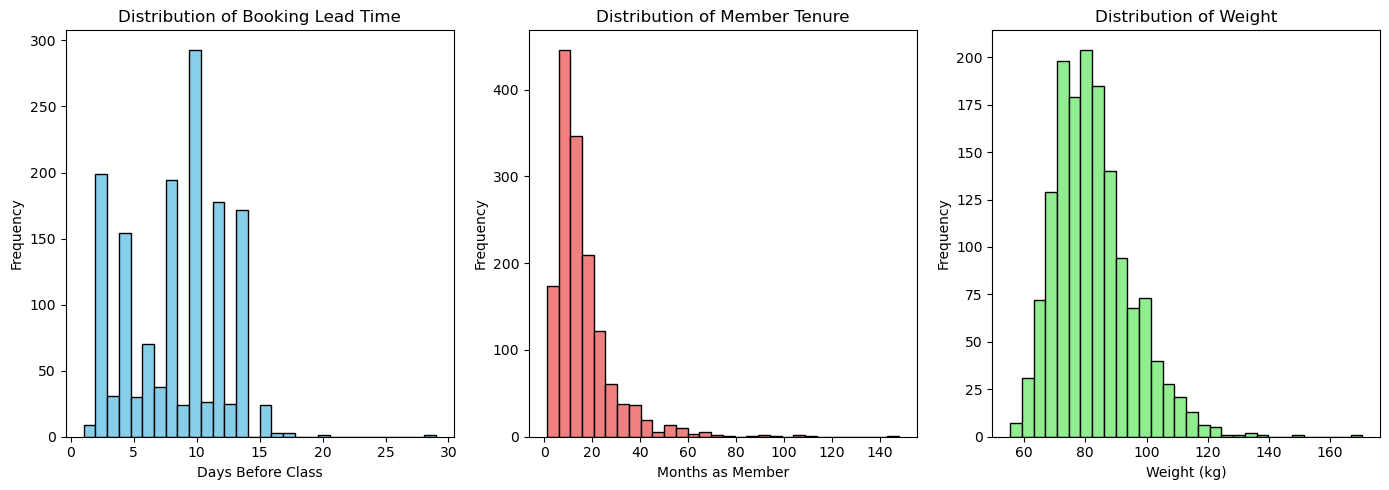

In [34]:
plots_config = [
    {'column': 'days_before', 'color': 'skyblue', 'xlabel': 'Days Before Class', 'title': 'Distribution of Booking Lead Time'},
    {'column': 'months_as_member', 'color': 'lightcoral', 'xlabel': 'Months as Member', 'title': 'Distribution of Member Tenure'},
    {'column': 'weight', 'color': 'lightgreen', 'xlabel': 'Weight (kg)', 'title': 'Distribution of Weight'}
]

plt.figure(figsize=(14, 5))

for i, config in enumerate(plots_config, 1):
    plt.subplot(1, 3, i)
    plt.hist(df[config['column']], bins=30, edgecolor='black', color=config['color'])
    plt.xlabel(config['xlabel'])
    plt.ylabel('Frequency')
    plt.title(config['title'])

plt.tight_layout()
plt.show()

The continuous variables show distinct characteristics: Member Tenure is heavily right-skewed, indicating a predominantly newer membership base with a few loyal outliers. Booking Lead Time shows discrete peaks suggesting scheduled booking behavior rather than a continuous flow. Finally, Weight follows a near-normal distribution, providing a representative sample of the general population.

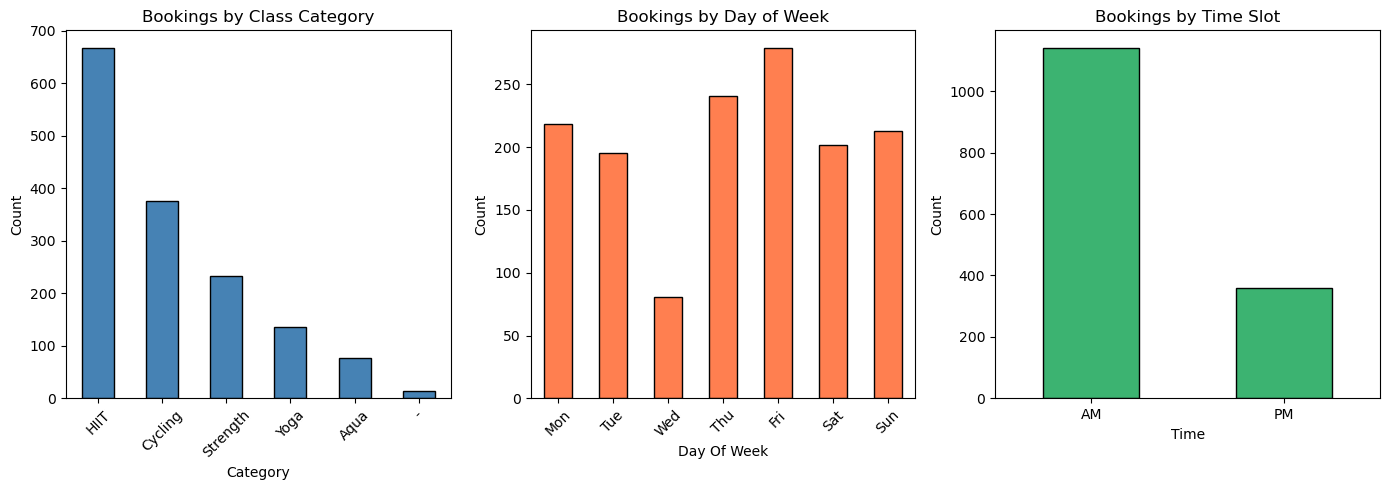

In [113]:
# Define the configuration for categorical plots
cat_plots = [
    {'col': 'category', 'color': 'steelblue', 'title': 'Bookings by Class Category', 'rot': 45},
    {'col': 'day_of_week', 'color': 'coral', 'title': 'Bookings by Day of Week', 'rot': 45, 
     'order': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']},
    {'col': 'time', 'color': 'mediumseagreen', 'title': 'Bookings by Time Slot', 'rot': 0}
]

plt.figure(figsize=(14, 5))

for i, config in enumerate(cat_plots, 1):
    plt.subplot(1, 3, i)
    data = df[config['col']].value_counts()
    # Reindex if a specific order is provided
    if 'order' in config:
        data = data.reindex(config['order'])
    data.plot(kind='bar', color=config['color'], edgecolor='black')
    
    plt.title(config['title'])
    plt.xlabel(config['col'].replace('_', ' ').title())
    plt.ylabel('Count')
    plt.xticks(rotation=config['rot'])

plt.tight_layout()
plt.show()

The categorical analysis reveals that HIIT is the primary driver of booking volume, though a small amount of 'dirty data' exists in the category labels. Demand is highest at the end of the work week (Friday) and heavily skewed toward morning (AM) sessions. The mid-week drop on Wednesday represents a potential opportunity for growth or a need for schedule optimization.

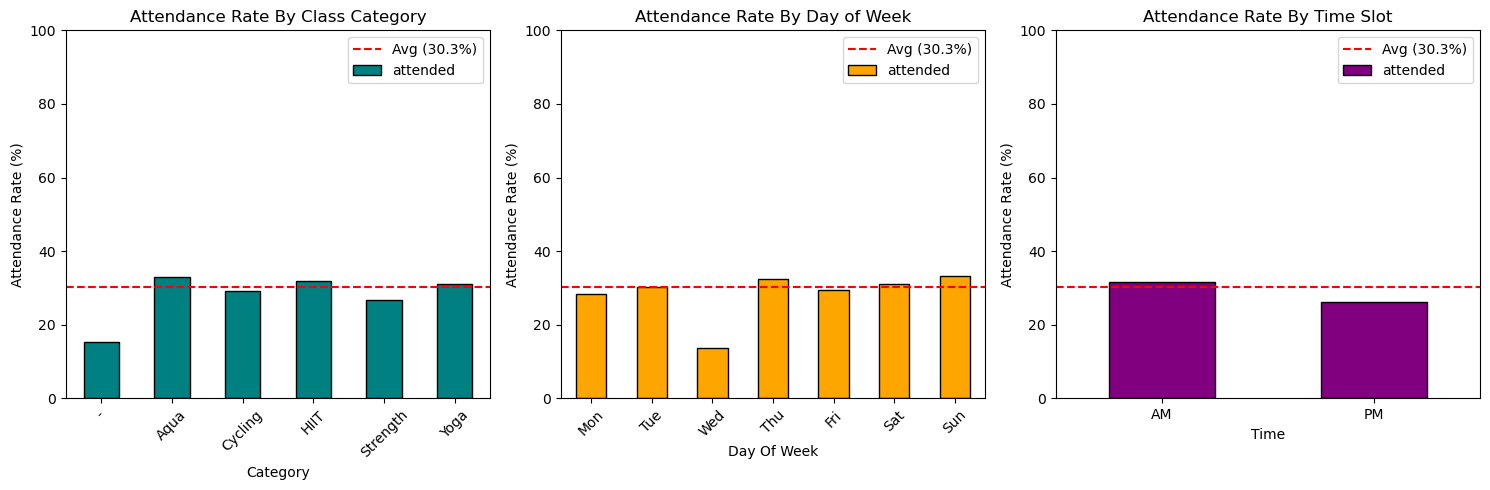

In [40]:
# 1. Pre-calculate the global average for the reference line
overall_avg = df['attended'].mean() * 100
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 2. Define the configuration
rate_plots = [
    {'col': 'category', 'color': 'teal', 'title': 'By Class Category', 'rot': 45, 'order': None},
    {'col': 'day_of_week', 'color': 'orange', 'title': 'By Day of Week', 'rot': 45, 'order': day_order},
    {'col': 'time', 'color': 'purple', 'title': 'By Time Slot', 'rot': 0, 'order': None}
]

plt.figure(figsize=(15, 5))

for i, config in enumerate(rate_plots, 1):
    plt.subplot(1, 3, i)
    
    # Group and calculate mean
    data = df.groupby(config['col'])['attended'].mean() * 100
    
    # Reindex if an order is specified
    if config['order']:
        data = data.reindex(config['order'])
        
    # Plotting
    data.plot(kind='bar', color=config['color'], edgecolor='black')
    
    # Add the overall average line
    plt.axhline(y=overall_avg, color='red', linestyle='--', label=f'Avg ({overall_avg:.1f}%)')
    
    # Formatting
    plt.title(f"Attendance Rate {config['title']}")
    plt.xlabel(config['col'].replace('_', ' ').title())
    plt.ylabel('Attendance Rate (%)')
    plt.xticks(rotation=config['rot'])
    plt.ylim(0, 100)
    plt.legend()

plt.tight_layout()
plt.show()

While the global attendance rate is 30.3%, significant variance exists across segments. Aqua and Sunday sessions show the highest member commitment. Conversely, Wednesday represents a critical failure point with an attendance rate of only 14%, less than half the gym's average. Additionally, morning sessions are consistently more reliable than evening ones.

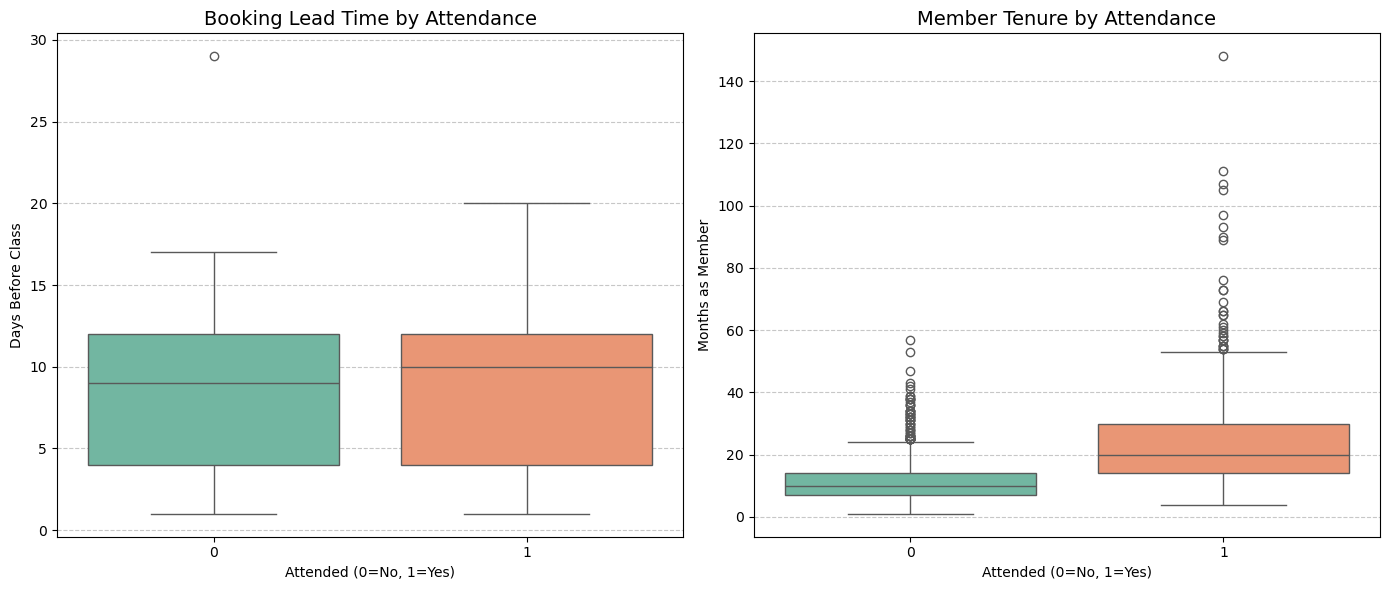

In [43]:
# Configuration for the two continuous variables
box_configs = [
    {'y': 'days_before', 'label': 'Days Before Class', 'title': 'Booking Lead Time'},
    {'y': 'months_as_member', 'label': 'Months as Member', 'title': 'Member Tenure'}
]

plt.figure(figsize=(14, 6))

for i, config in enumerate(box_configs, 1):
    plt.subplot(1, 2, i)
    
    # Seaborn makes the colors and styling much cleaner automatically
    sns.boxplot(data=df, x='attended', y=config['y'], palette='Set2', hue='attended', legend=False)
    
    plt.title(f"{config['title']} by Attendance", fontsize=14)
    plt.xlabel('Attended (0=No, 1=Yes)')
    plt.ylabel(config['label'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Bivariate analysis reveals that while Booking Lead Time has negligible impact on attendance, Member Tenure is a key differentiator. The median tenure for attending members is roughly double that of non-attending members. This suggests that attendance is a habit built over time, and the gym faces its highest risk of 'no-shows' from members within their first 12 months of joining.

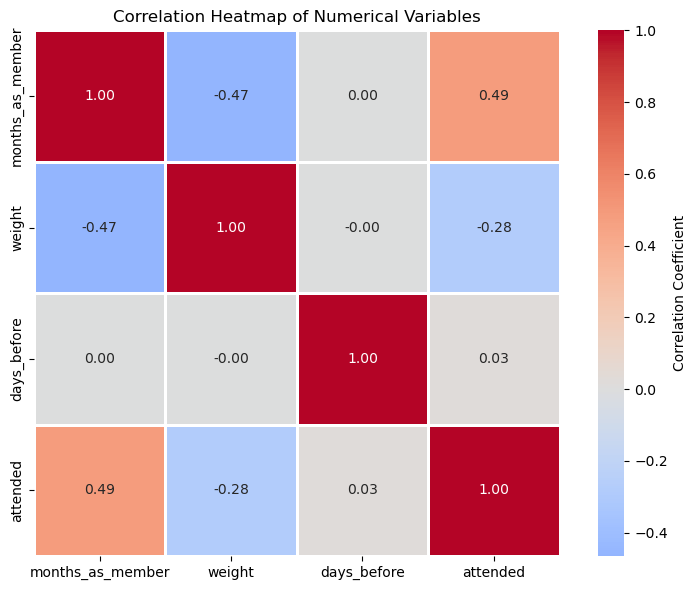

In [46]:
plt.figure(figsize=(8, 6))

# Select only numerical columns for correlation
numerical_cols = ['months_as_member', 'weight', 'days_before', 'attended']
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

Member Tenure shows the strongest positive relationship with attendance (r = 0.49), making it a primary driver for predictive modeling. We also observe a notable negative correlation between Weight and Tenure (r = -0.47), suggesting that long-term membership is associated with lower body weight. Finally, Booking Lead Time shows no statistical correlation with attendance (r = 0.03), indicating it is not a meaningful predictor of member behavior.

In [59]:
df['days_before'] = df['days_before'].fillna(df['days_before'].median())

In [61]:
df_ml = pd.get_dummies(df, columns=['category', 'day_of_week', 'time'], drop_first=True)

In [63]:
# Split features and target
X = df_ml.drop('attended', axis=1)
y = df_ml['attended']

In [65]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [67]:
# Feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
# Balancing (SMOTE)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [73]:
# Train and Evaluate
lr_balanced = LogisticRegression(random_state=42)
lr_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)

print("\nLogistic Regression Performance (With Balancing):")
print(classification_report(y_test, y_pred_lr_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_balanced))


Logistic Regression Performance (With Balancing):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       293
           1       0.64      0.64      0.64       157

    accuracy                           0.75       450
   macro avg       0.73      0.73      0.73       450
weighted avg       0.75      0.75      0.75       450

Confusion Matrix:
[[237  56]
 [ 56 101]]


The logistic regression model achieved an overall accuracy of 75%, indicating reasonable baseline predictive performance in classifying attendance outcomes. The confusion matrix shows that 237 non-attendance cases and 101 attendance cases were correctly classified, while false positives and false negatives were evenly distributed at 56 each, suggesting balanced misclassification. Model performance was stronger for predicting non-attendance (precision, recall, and F1-score of 0.81) than attendance (0.64 across all three metrics), indicating that attendance was more difficult to predict. The use of class balancing appears to have improved detection of the minority class and produced more balanced performance across outcomes. 

In [76]:
#Random Forest
rf_balanced = RandomForestClassifier(random_state=42)
rf_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_rf_balanced = rf_balanced.predict(X_test_scaled)

print("\nRandom Forest Performance (With Balancing):")
print(classification_report(y_test, y_pred_rf_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))


Random Forest Performance (With Balancing):
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       293
           1       0.63      0.59      0.61       157

    accuracy                           0.74       450
   macro avg       0.71      0.70      0.70       450
weighted avg       0.73      0.74      0.73       450

Confusion Matrix:
[[238  55]
 [ 64  93]]


The balanced random forest model achieved an overall accuracy of 74%, indicating similar baseline predictive performance to the logistic regression model. The confusion matrix shows that 238 non-attendance cases and 93 attendance cases were correctly classified, while the model produced 55 false positives and 64 false negatives. Performance was stronger for predicting non-attendance (precision 0.79, recall 0.81, F1-score 0.80) than attendance (precision 0.63, recall 0.59, F1-score 0.61), suggesting the model was less effective at identifying attendees than no-shows. While class balancing helped support minority class prediction, recall for attendance remained relatively modest, indicating some difficulty capturing positive cases.

In [81]:
#Hyperparameter Tuning (Random Forest)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_search_rf.fit(X_train_balanced, y_train_balanced)

print("\nBest Parameters for Random Forest:")
print(grid_search_rf.best_params_)

# Evaluate tuned Random Forest
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)

print("\nTuned Random Forest Performance:")
print(classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))


Best Parameters for Random Forest:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       293
           1       0.63      0.57      0.60       157

    accuracy                           0.73       450
   macro avg       0.70      0.69      0.70       450
weighted avg       0.73      0.73      0.73       450

Confusion Matrix:
[[240  53]
 [ 68  89]]


The tuned random forest model, using optimised hyperparameters (max depth of 20, minimum samples split of 2, and 100 estimators), achieved an overall accuracy of 73%, providing similar predictive performance to the untuned model. The confusion matrix shows that 240 non-attendance cases and 89 attendance cases were correctly classified, while the model produced 53 false positives and 68 false negatives. Performance remained stronger for predicting non-attendance (precision 0.78, recall 0.82, F1-score 0.80) than attendance (precision 0.63, recall 0.57, F1-score 0.60), suggesting the model continued to face challenges identifying attendees accurately. Despite hyperparameter tuning, improvements were limited, indicating that model performance may be constrained more by feature signal than parameter choice alone.

In [84]:
#Cross-Validation (Random Forest)
cv_scores_rf = cross_val_score(best_rf, X_train_balanced, y_train_balanced, cv=5, scoring='accuracy')
print("\nRandom Forest Cross-Validation Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean())


Random Forest Cross-Validation Scores: [0.83443709 0.75415282 0.82724252 0.85049834 0.85714286]
Mean CV Accuracy: 0.8246947261886428


In [86]:
#Gradient Boosting Trees (GBT)
gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(X_train_balanced, y_train_balanced)
y_pred_gbt = gbt.predict(X_test_scaled)

print("\nGradient Boosting Trees Performance:")
print(classification_report(y_test, y_pred_gbt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbt))


Gradient Boosting Trees Performance:
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       293
           1       0.66      0.67      0.66       157

    accuracy                           0.76       450
   macro avg       0.74      0.74      0.74       450
weighted avg       0.76      0.76      0.76       450

Confusion Matrix:
[[238  55]
 [ 52 105]]


The gradient boosting model achieved an overall accuracy of 76%, representing the strongest predictive performance among the models tested so far. The confusion matrix shows that 238 non-attendance cases and 105 attendance cases were correctly classified, while the model produced 55 false positives and 52 false negatives. Performance was strong for predicting non-attendance (precision 0.82, recall 0.81, F1-score 0.82) and improved relative to previous models for predicting attendance (precision 0.66, recall 0.67, F1-score 0.66), indicating better identification of the minority class. Compared with the logistic regression and random forest models, gradient boosting produced more balanced classification performance across both outcomes. 

### Assignment #2

In [91]:
# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

# Perform Grid Search
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_balanced, y_train_balanced)

# Best Model
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

print("Best Parameters for Logistic Regression:", grid_lr.best_params_)
print("\nFine-Tuned Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Best Parameters for Logistic Regression: {'C': 1, 'max_iter': 1000, 'solver': 'liblinear'}

Fine-Tuned Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       293
           1       0.64      0.65      0.65       157

    accuracy                           0.75       450
   macro avg       0.73      0.73      0.73       450
weighted avg       0.75      0.75      0.75       450

Confusion Matrix:
[[236  57]
 [ 55 102]]


The fine-tuned logistic regression model achieved an overall accuracy of 75%, maintaining strong baseline predictive performance. The confusion matrix shows that 236 non-attendance cases and 102 attendance cases were correctly classified, while the model produced 57 false positives and 55 false negatives, indicating relatively balanced misclassification. Performance remained stronger for predicting non-attendance (precision 0.81, recall 0.81, F1-score 0.81) than attendance (precision 0.64, recall 0.65, F1-score 0.65), although attendance detection showed a slight improvement over the untuned model.

In [94]:
# Define the parameter grid for GBT
param_grid_gbt = {
    'n_estimators': [100, 200], # number of sequential trees to be built.
    'learning_rate': [0.01, 0.1, 0.2], # step size applied to each tree's contribution
    'max_depth': [3, 4, 5], # maximum number of levels in each individual tree
    'subsample': [0.8, 1.0] # fraction of the data to be used for fitting each individual tree
}

# Perform Grid Search
grid_gbt = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gbt, cv=5, scoring='f1')
grid_gbt.fit(X_train_balanced, y_train_balanced)

# Best Model
best_gbt = grid_gbt.best_estimator_
y_pred_gbt = best_gbt.predict(X_test_scaled)

print("Best Parameters for GBT:", grid_gbt.best_params_)
print("\nFine-Tuned GBT Performance:")
print(classification_report(y_test, y_pred_gbt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbt))

Best Parameters for GBT: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Fine-Tuned GBT Performance:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       293
           1       0.64      0.65      0.64       157

    accuracy                           0.75       450
   macro avg       0.72      0.73      0.72       450
weighted avg       0.75      0.75      0.75       450

Confusion Matrix:
[[235  58]
 [ 55 102]]


The fine-tuned gradient boosting model, using optimised hyperparameters achieved an overall accuracy of 75%, maintaining strong predictive performance while performing similarly to the untuned model. The confusion matrix shows that 235 non-attendance cases and 102 attendance cases were correctly classified, while the model produced 58 false positives and 55 false negatives. Performance remained stronger for predicting non-attendance (precision 0.81, recall 0.80, F1-score 0.81) than attendance (precision 0.64, recall 0.65, F1-score 0.64), with relatively balanced classification performance across outcomes. While hyperparameter tuning did not lead to substantial improvements over the original gradient boosting model, the results suggest the model remains effective at capturing predictive patterns in the data.

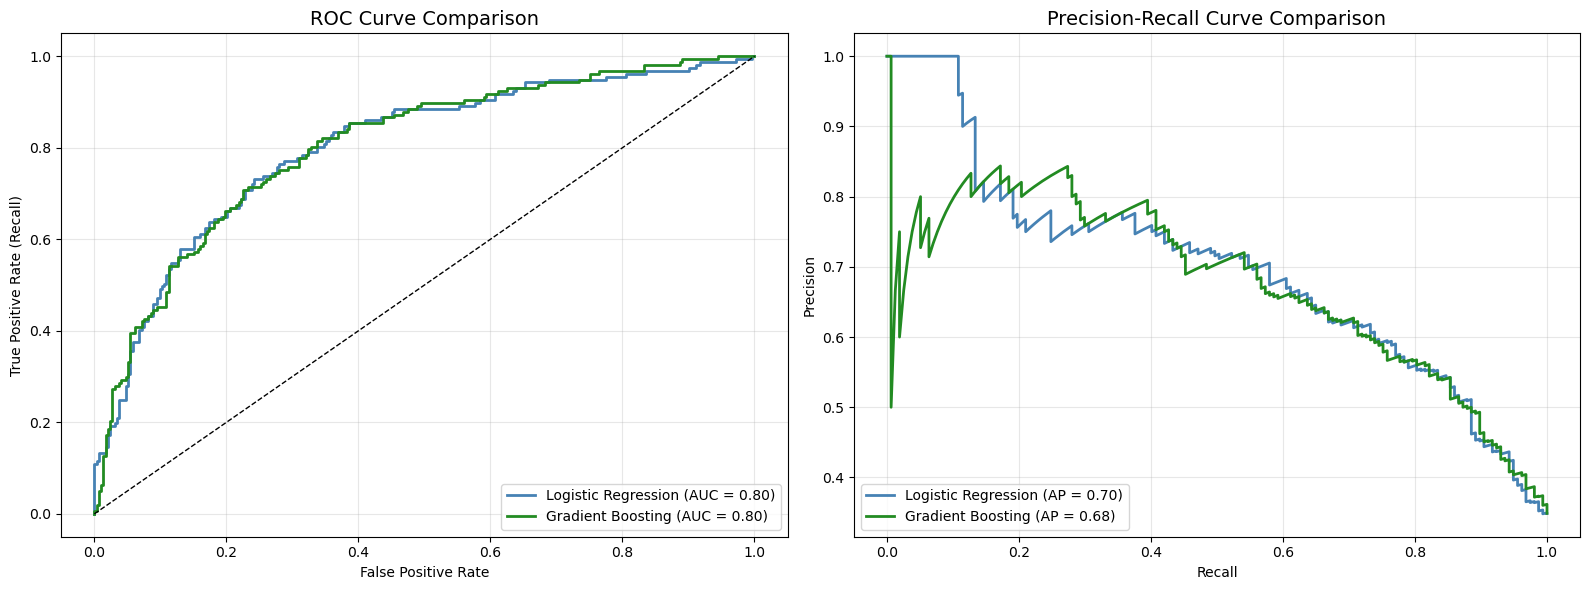

In [101]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Setup the figure for two comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models = [
    ('Logistic Regression', best_lr, 'steelblue'),
    ('Gradient Boosting', best_gbt, 'forestgreen')
]

for name, model, color in models:
    # Get predicted probabilities for the positive class (1)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    
    # ROC Curve Calculation 
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    
    # Precision-Recall Curve Calculation
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap_score = average_precision_score(y_test, y_probs)
    ax2.plot(recall, precision, color=color, lw=2, label=f'{name} (AP = {ap_score:.2f})')

# Formatting ROC Plot
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve Comparison', fontsize=14)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Formatting Precision-Recall Plot
ax2.set_title('Precision-Recall Curve Comparison', fontsize=14)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Despite the increased complexity of the Gradient Boosting model, Logistic Regression is the superior choice for this application. It matches the GBT's 0.80 AUC and demonstrates a higher Average Precision (0.70). Logistic Regression also offers greater transparency, making it easier for the fitness center to understand exactly which factors, such as member tenure, are driving class attendance.

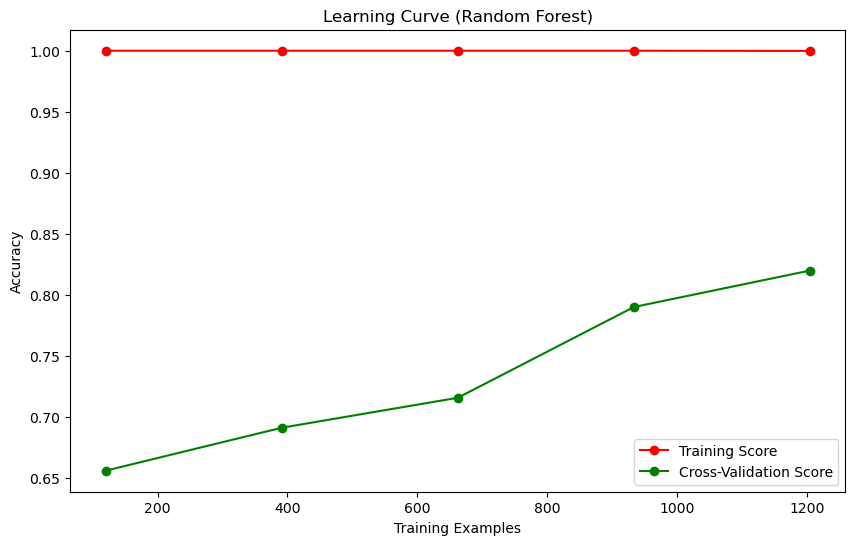

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py", line 665, in fit
    y = self._encode_y(

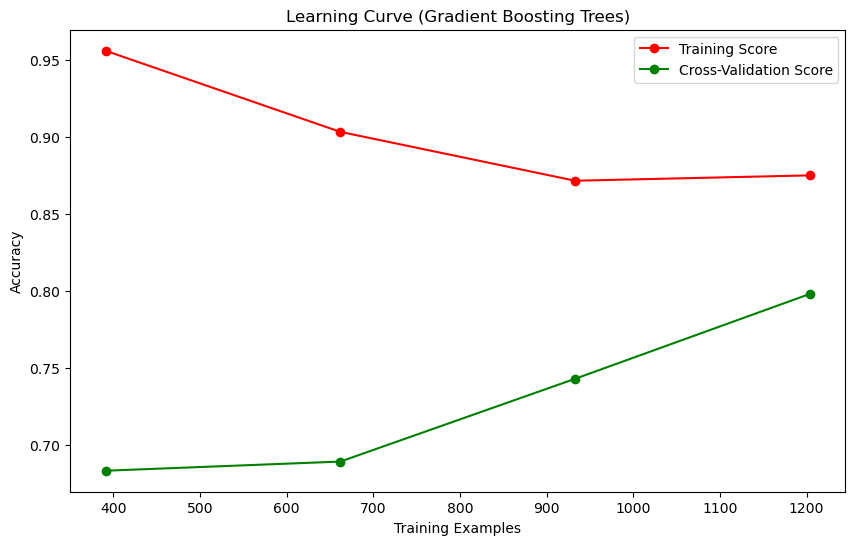

In [105]:
#Bias-Variance Tradeoff (Learning Curves)
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for Random Forest
plot_learning_curve(best_rf, "Learning Curve (Random Forest)", X_train_balanced, y_train_balanced)

# Plot learning curve for Gradient Boosting Trees
plot_learning_curve(gbt, "Learning Curve (Gradient Boosting Trees)", X_train_balanced, y_train_balanced)